# Homework: Data Exploration

## Name: <span style="color:blue"> *Abby Graber* </span>

## Utils

In [1]:
from typing import List, Dict, Tuple
import os
import gc
import traceback
import warnings
from pdb import set_trace

# Default seed
seed = 0

In [2]:
class TodoCheckFailed(Exception):
    pass

def todo_check(asserts, mute=False, **kwargs):
    locals().update(kwargs)
    failed_err = "You passed {}/{} and FAILED the following code checks:\n{}"
    failed = ""
    n_failed = 0
    for check, (condi, err) in enumerate(asserts):
        exc_failed = False
        if isinstance(condi, str):
            try:
                passed = eval(condi)
            except Exception:
                exc_failed = True
                n_failed += 1
                failed += f"\nCheck [{check+1}]: Failed to execute check [{check+1}] due to the following error...\n{traceback.format_exc()}"
        elif isinstance(condi, bool):
            passed = condi
        else:
            raise ValueError("asserts must be a list of strings or bools")

        if not exc_failed and not passed:
            n_failed += 1
            failed += f"\nCheck [{check+1}]: Failed\n\tTip: {err}\n"

    if len(failed) != 0:
        passed = len(asserts) - n_failed
        err = failed_err.format(passed, len(asserts), failed)
        raise TodoCheckFailed(err.format(failed))
    if not mute: print("Your code PASSED all the code checks!")


# Data Exploration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
print(f"The current path for your notebook is:\n {os.getcwd()}\n")
print(f"Your notebook is currently in the following directory:\n {os.path.basename(os.getcwd())}")

The current path for your notebook is:
 c:\Users\abbyg\Downloads\data-visualization

Your notebook is currently in the following directory:
 data-visualization


In [5]:
df_22 = None
df_13 = None
df_05 = None

# Load datasets
df_22 = pd.read_csv('22zpallagi.csv')
df_13 = pd.read_csv('13zpallagi.csv') 
df_05 = pd.read_csv('zipcode05.csv') 

C:\Users\abbyg\AppData\Local\Temp\ipykernel_13848\3534217785.py:8: DtypeWarning: Columns (38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_05 = pd.read_csv('zipcode05.csv')


#### Table Display

In [6]:
# 2022 Data
display(df_22)

,STATEFIPS,STATE,zipcode,agi_stub,N1,mars1,MARS2,MARS4,ELF,CPREP,...,N85300,A85300,N11901,A11901,N11900,A11900,N11902,A11902,N12000,A12000
0,1,AL,0,1,659530.0,422590.0,71000.0,154700.0,610780.0,24340.0,...,0.0,0.0,63060.0,54280.0,543620.0,1559881.0,541480.0,1552563.0,2250.0,5031.0
1,1,AL,0,2,533640.0,276250.0,101050.0,141040.0,499310.0,15050.0,...,0.0,0.0,100320.0,130848.0,430380.0,1339883.0,427830.0,1329439.0,2780.0,8556.0
2,1,AL,0,3,304870.0,134050.0,109980.0,51600.0,286110.0,9600.0,...,0.0,0.0,88750.0,186002.0,216080.0,585162.0,212990.0,573080.0,4520.0,12589.0
3,1,AL,0,4,193020.0,56350.0,113100.0,19090.0,181390.0,4530.0,...,0.0,0.0,67040.0,189833.0,124860.0,403052.0,121760.0,388581.0,2840.0,12190.0
4,1,AL,0,5,315700.0,45000.0,252660.0,12180.0,297930.0,9000.0,...,140.0,63.0,138270.0,657283.0,177730.0,748507.0,169080.0,671684.0,10940.0,80141.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166126,56,WY,99999,2,3100.0,1860.0,790.0,390.0,2960.0,60.0,...,0.0,0.0,580.0,688.0,2380.0,6080.0,2330.0,5841.0,50.0,75.0
166127,56,WY,99999,3,2130.0,1000.0,860.0,210.0,1990.0,70.0,...,0.0,0.0,530.0,1168.0,1500.0,4055.0,1440.0,3818.0,30.0,35.0
166128,56,WY,99999,4,1620.0,530.0,960.0,120.0,1570.0,30.0,...,0.0,0.0,460.0,1390.0,1070.0,3482.0,1010.0,3211.0,50.0,108.0
166129,56,WY,99999,5,2710.0,550.0,2070.0,90.0,2610.0,60.0,...,0.0,0.0,1020.0,5376.0,1600.0,7849.0,1440.0,6455.0,170.0,1011.0


In [7]:
# 2010 Data
display(df_13)

,STATEFIPS,STATE,zipcode,agi_stub,N1,MARS1,MARS2,MARS4,PREP,N2,...,N10300,A10300,N85330,A85330,N85300,A85300,N11901,A11901,N11902,A11902
0,1,AL,0,1,870380.0,488030.0,122290.0,247000.0,500770.0,1452580.0,...,371450.0,318777.0,0.0,0.0,0.0,0.0,59580.0,44367.0,767170.0,2005593.0
1,1,AL,0,2,490960.0,195840.0,155230.0,125280.0,286130.0,1027850.0,...,386570.0,935430.0,0.0,0.0,0.0,0.0,65850.0,94281.0,418070.0,1192755.0
2,1,AL,0,3,258810.0,72710.0,146880.0,32860.0,157670.0,594910.0,...,249040.0,1310745.0,0.0,0.0,0.0,0.0,58810.0,125566.0,194360.0,552938.0
3,1,AL,0,4,163290.0,24860.0,126480.0,9790.0,98920.0,424160.0,...,162050.0,1374682.0,0.0,0.0,0.0,0.0,41950.0,113997.0,116830.0,385953.0
4,1,AL,0,5,192050.0,16930.0,168170.0,5450.0,115290.0,538120.0,...,191470.0,3460632.0,650.0,146.0,240.0,63.0,73380.0,358812.0,110760.0,441951.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166735,56,WY,99999,2,5920.0,3290.0,1590.0,910.0,3220.0,11740.0,...,4910.0,14449.0,0.0,0.0,0.0,0.0,880.0,1551.0,4800.0,11533.0
166736,56,WY,99999,3,3650.0,1510.0,1770.0,310.0,2240.0,8150.0,...,3450.0,21319.0,0.0,0.0,0.0,0.0,760.0,1856.0,2680.0,7474.0
166737,56,WY,99999,4,2660.0,730.0,1770.0,150.0,1710.0,6520.0,...,2620.0,25373.0,0.0,0.0,0.0,0.0,620.0,2347.0,1850.0,6384.0
166738,56,WY,99999,5,3020.0,500.0,2450.0,70.0,2150.0,7780.0,...,3000.0,57624.0,0.0,0.0,0.0,0.0,1100.0,6595.0,1610.0,7796.0


In [8]:
#1998 Data
display(df_05)

,STATE,zipcode,agi_stub,N1,n2,n6,A00100,n00200,a00200,n00300,...,n05800,a05800,n09200,a09200,n11000,a11000,PREP,agi_04470,agi_19700,agi_18300
0,AK,99501,1,1459,1865,342,1709,994,5588,409,...,609,43,596,116,528,394,730,208,131,-3789
1,AK,99501,2,1713,2555,683,29943,1487,24052,427,...,1531,1383,1302,1436,405,993,927,2345,1625,1964
2,AK,99501,3,1896,2944,736,67861,1705,57409,710,...,1878,6076,1726,5896,158,168,905,11862,8300,9817
3,AK,99501,4,839,1421,303,51347,684,36871,536,...,836,6134,827,6245,0,0,467,20618,17217,18771
4,AK,99501,5,417,794,153,35984,323,24282,327,...,416,4732,415,5134,0,0,227,20770,17573,19827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231001,WY,83414,2,28,49,14,532,19,333,13,...,18,17,17,22,0,0,17,0,0,0
231002,WY,83414,3,28,73,27,1080,24,744,18,...,25,54,24,75,0,0,20,713,508,560
231003,WY,83414,4,28,78,26,1979,19,1062,18,...,26,153,24,146,0,0,17,"1,354","1,122","1,354"
231004,WY,83414,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# Get and display column names (features)
feature_names_22 = None
feature_names_13 = None
feature_names_05 = None

feature_names_22 = df_22.columns
feature_names_13 = df_13.columns
feature_names_05 = df_05.columns

print(f'The feature names for 2022 are:\n{feature_names_22.values}\n')
print(f'The feature names for 2013 are:\n{feature_names_13.values}\n')
print(f'The feature names for 2005 are:\n{feature_names_05.values}\n')

The feature names for 2022 are:
['STATEFIPS' 'STATE' 'zipcode' 'agi_stub' 'N1' 'mars1' 'MARS2' 'MARS4'
 'ELF' 'CPREP' 'PREP' 'DIR_DEP' 'VRTCRIND' 'N2' 'TOTAL_VITA' 'VITA' 'TCE'
 'VITA_EIC' 'RAC' 'ELDERLY' 'A00100' 'N02650' 'A02650' 'N00200' 'A00200'
 'N00300' 'A00300' 'N00400' 'A00400' 'N00600' 'A00600' 'N00650' 'A00650'
 'N00700' 'A00700' 'N00900' 'A00900' 'N01000' 'A01000' 'N01400' 'A01400'
 'N01700' 'A01700' 'SCHF' 'N02300' 'A02300' 'N02500' 'A02500' 'N26270'
 'A26270' 'N25870' 'A25870' 'N02900' 'A02900' 'N03220' 'A03220' 'N03300'
 'A03300' 'N03270' 'A03270' 'N03150' 'A03150' 'N03210' 'A03210' 'N04450'
 'A04450' 'N04100' 'A04100' 'N04200' 'A04200' 'N04470' 'A04470' 'A00101'
 'N17000' 'A17000' 'N18425' 'A18425' 'N18450' 'A18450' 'N18500' 'A18500'
 'N18800' 'A18800' 'N18460' 'A18460' 'N18300' 'A18300' 'N19300' 'A19300'
 'N19500' 'A19500' 'N19530' 'A19530' 'N19570' 'A19570' 'N19700' 'A19700'
 'N20950' 'A20950' 'N04475' 'A04475' 'N04800' 'A04800' 'N05800' 'A05800'
 'N09600' 'A09600' 'N0

### <span style="color:white"> Features to Include </span>
   `zipcode`  

   `state`  

   `N1` (Number of returns)  

   `A00100` (Total AGI)  

   `agi_stub` (Income bracket)  

We need to add a `year` column in order to differentiate each dataset when comparing them.

Consolodate datasets for data visualization and add a `year` column

In [10]:
# Define the columns we need
cols = ['STATE', 'zipcode', 'N1', 'A00100', 'agi_stub']

# Reload each dataframe with only the specified columns
df_22 = pd.read_csv('22zpallagi.csv', usecols=cols, dtype={'zipcode': str})
df_13 = pd.read_csv('13zpallagi.csv', usecols=cols, dtype={'zipcode': str}) 
df_05 = pd.read_csv('zipcode05.csv', usecols=cols, dtype={'zipcode': str}) 

# Add year to each dataframe
df_22['YEAR'] = 2022
df_13['YEAR'] = 2013
df_05['YEAR'] = 2005

# Get and display new column names (features)
feature_names_22 = None
feature_names_13 = None
feature_names_05 = None

feature_names_22 = df_22.columns
feature_names_13 = df_13.columns
feature_names_05 = df_05.columns

print(f'The feature names for 2022 are:\n{feature_names_22.values}\n')
print(f'The feature names for 2013 are:\n{feature_names_13.values}\n')
print(f'The feature names for 2005 are:\n{feature_names_05.values}\n')

The feature names for 2022 are:
['STATE' 'zipcode' 'agi_stub' 'N1' 'A00100' 'YEAR']

The feature names for 2013 are:
['STATE' 'zipcode' 'agi_stub' 'N1' 'A00100' 'YEAR']

The feature names for 2005 are:
['STATE' 'zipcode' 'agi_stub' 'N1' 'A00100' 'YEAR']



# Master Dataframe

Combine all datasets into one master dataframe

In [11]:
master_df = pd.concat([df_05, df_13, df_22],ignore_index=True)

print(master_df.head())
print(master_df.tail())

  STATE zipcode  agi_stub      N1   A00100  YEAR
0    AK   99501         1  1459.0   1709.0  2005
1    AK   99501         2  1713.0  29943.0  2005
2    AK   99501         3  1896.0  67861.0  2005
3    AK   99501         4   839.0  51347.0  2005
4    AK   99501         5   417.0  35984.0  2005
       STATE zipcode  agi_stub      N1    A00100  YEAR
563872    WY   99999         2  3100.0  114043.0  2022
563873    WY   99999         3  2130.0  131073.0  2022
563874    WY   99999         4  1620.0  140490.0  2022
563875    WY   99999         5  2710.0  370344.0  2022
563876    WY   99999         6  1070.0  710050.0  2022


# Data Visualization and Exploration

## Exploring


In [12]:
d22_shape = None
d13_shape = None
d05_shape = None
master_shape = None

d22_shape = df_22.shape
d13_shape = df_13.shape
d05_shape = df_05.shape
master_shape = master_df.shape

print(f'The 2022 dataset shape is: {d22_shape}')
print(f'The 2013 dataset shape is: {d13_shape}')
print(f'The 2005 dataset shape is: {d05_shape}')
print(f'The master dataset shape is: {master_shape}')

The 2022 dataset shape is: (166131, 6)
The 2013 dataset shape is: (166740, 6)
The 2005 dataset shape is: (231006, 6)
The master dataset shape is: (563877, 6)


In [13]:
# Display summary of the data
print(df_22.info())  
print(df_13.info())  
print(df_05.info())
print(master_df.info())  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166131 entries, 0 to 166130
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STATE     166131 non-null  object 
 1   zipcode   166131 non-null  object 
 2   agi_stub  166131 non-null  int64  
 3   N1        166131 non-null  float64
 4   A00100    166131 non-null  float64
 5   YEAR      166131 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 7.6+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166740 entries, 0 to 166739
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STATE     166740 non-null  object 
 1   zipcode   166740 non-null  object 
 2   agi_stub  166740 non-null  int64  
 3   N1        166740 non-null  float64
 4   A00100    166740 non-null  float64
 5   YEAR      166740 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 7.6+ MB
None
<class

## Visualization

### Total AGI % change per ZIP

Shows long-term vs recent trends (2005 → 2013 → 2022).  
Detects areas that were historically growing but are now declining (i.e. emerging risk zones).  

Chart Captures -  
Total welth flowing in or out of ZIP  
Economic size expansion or contraction  
Exposure risk for a bank lending in that region 

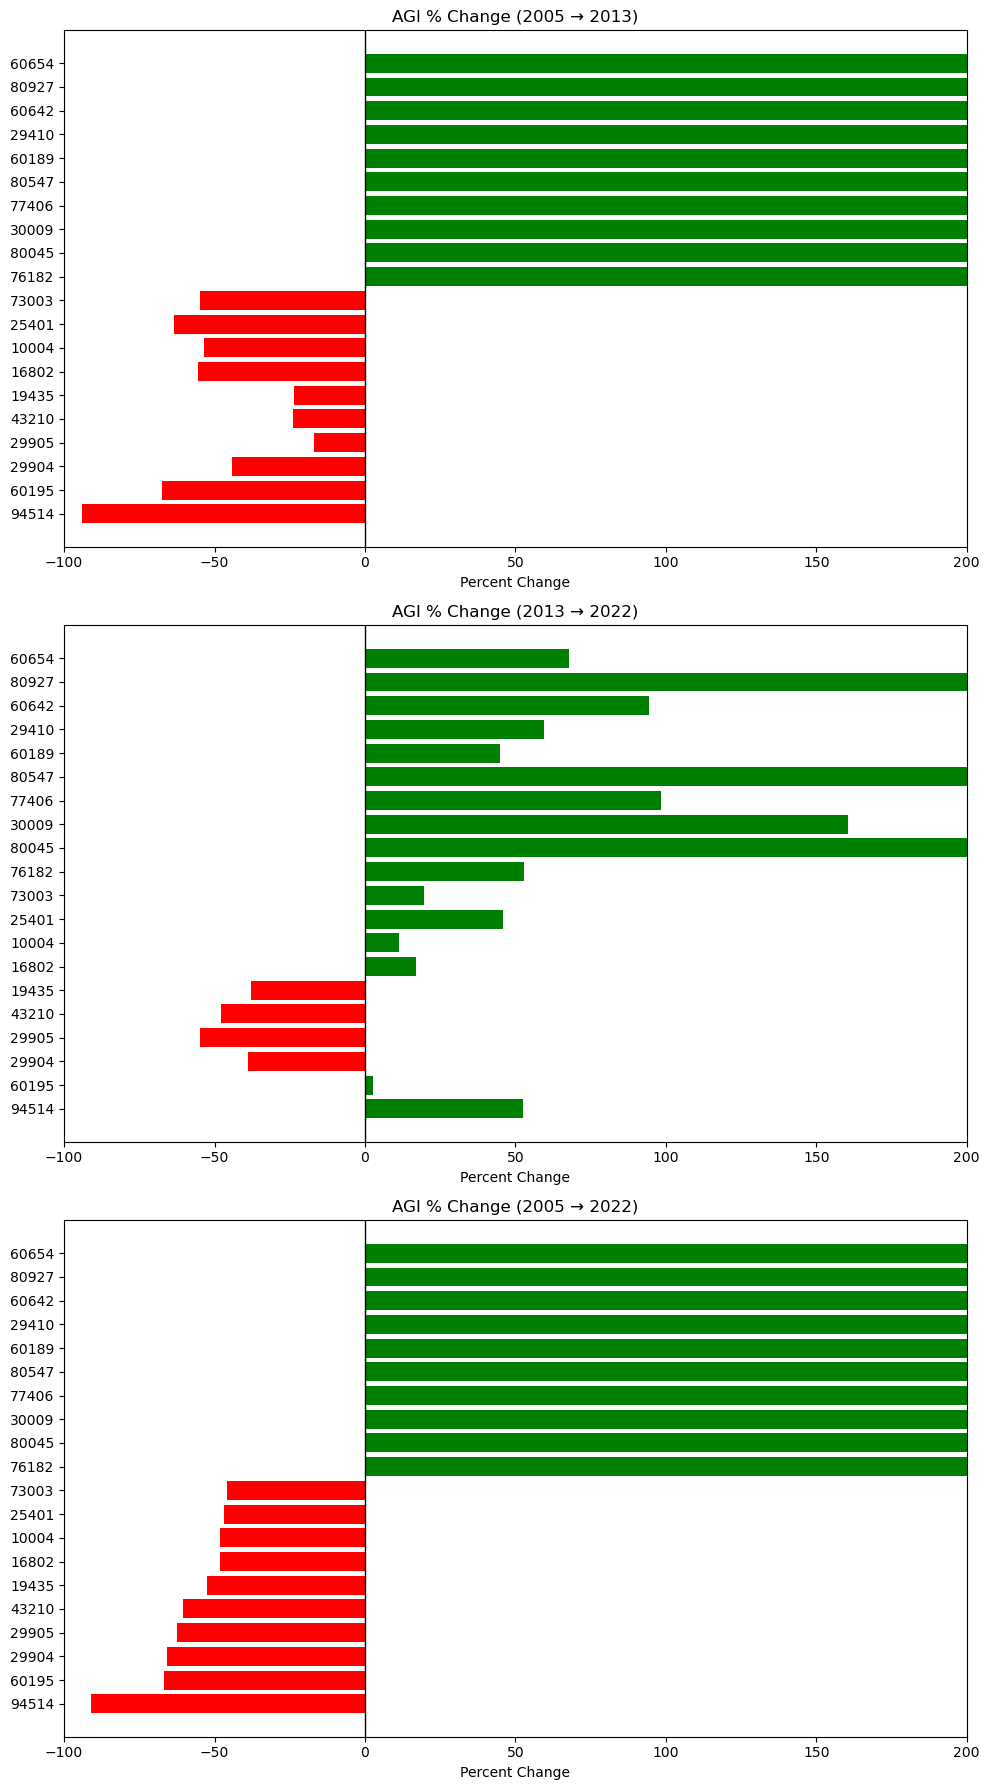

In [14]:
# Aggregragte total AGI per ZIP per year
zip_year_agi = (
    master_df
    .groupby(['zipcode', 'YEAR'])['A00100']
    .sum()
    .reset_index()
)

# Pivot years to columns
zip_pivot = zip_year_agi.pivot(
    index='zipcode',
    columns='YEAR',
    values='A00100'
)

zip_pivot = zip_pivot.dropna()

# Compute all three period changes
zip_pivot['pct_05_13'] = ((zip_pivot[2013] - zip_pivot[2005]) / zip_pivot[2005]) * 100
zip_pivot['pct_13_22'] = ((zip_pivot[2022] - zip_pivot[2013]) / zip_pivot[2013]) * 100
zip_pivot['pct_05_22'] = ((zip_pivot[2022] - zip_pivot[2005]) / zip_pivot[2005]) * 100

# Select extreme zipcodes
top_n = 10

top_growth = zip_pivot.sort_values('pct_05_22', ascending=False).head(top_n)
top_decline = zip_pivot.sort_values('pct_05_22').head(top_n)

plot_df = pd.concat([top_decline, top_growth])
plot_df = plot_df.sort_values('pct_05_22')

# Plotting function
def plot_diverging(ax, data, column, title):
    colors = ['red' if x < 0 else 'green' for x in data[column]]
    
    ax.barh(
        data.index,
        data[column],
        color=colors
    )
    
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Percent Change')
    ax.set_xlim(-100, 200)  # adjust if needed

# Create 3 diverging charts
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

plot_diverging(axes[0], plot_df, 'pct_05_13', 'AGI % Change (2005 → 2013)')
plot_diverging(axes[1], plot_df, 'pct_13_22', 'AGI % Change (2013 → 2022)')
plot_diverging(axes[2], plot_df, 'pct_05_22', 'AGI % Change (2005 → 2022)')

plt.tight_layout()
plt.show()

In [15]:
# Average AGI
master_df['avg_agi'] = master_df['A00100'] / master_df['N1']

# Pivot for easier comparison
pivot_df = master_df.pivot_table(index='zipcode', columns='YEAR', values=['A00100', 'N1', 'avg_agi'])

pivot_df.columns = [f"{col[0]}_{col[1]}" for col in pivot_df.columns]

pivot_feature_names = None
pivot_feature_names = pivot_df.columns
print(f'The feature names for the pivot dataframe are:\n{pivot_feature_names.values}\n')

The feature names for the pivot dataframe are:
['A00100_2005' 'A00100_2013' 'A00100_2022' 'N1_2005' 'N1_2013' 'N1_2022'
 'avg_agi_2005' 'avg_agi_2013' 'avg_agi_2022']



### Average AGI per tax return % change

Highlights the ZIP codes with the largest positive and negative changes.  
Quickly identifies “red flag” areas where lending risk is highest.  
Centered at 0 → easy to see shrinking vs booming areas.  

Chart captures:  
Change in income per household  
Income quality shifts  
Gentrification vs middle-class erosion  

C:\Users\abbyg\AppData\Local\Temp\ipykernel_13848\3048144044.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


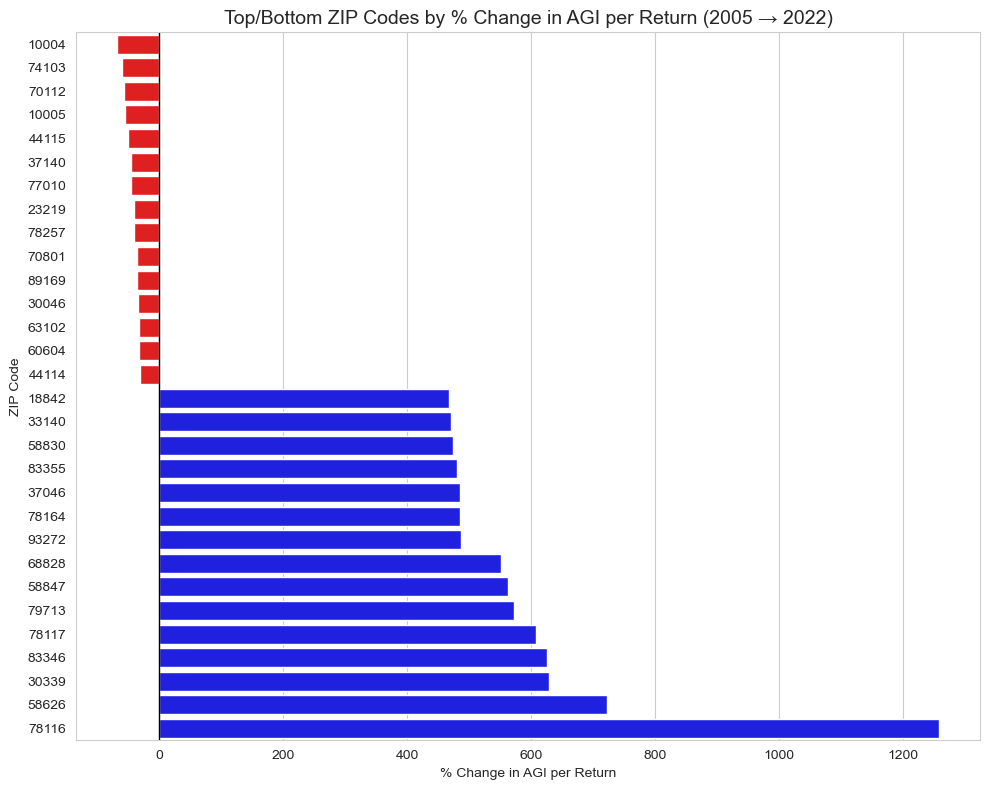

In [16]:
import seaborn as sns

# Compute AGI per return & % change
pivot_df["avg_agi_2005"] = pivot_df["A00100_2005"] / pivot_df["N1_2005"]
pivot_df["avg_agi_2022"] = pivot_df["A00100_2022"] / pivot_df["N1_2022"]

pivot_df["avg_agi_pct_change"] = ((pivot_df["avg_agi_2022"] - pivot_df["avg_agi_2005"]) / pivot_df["avg_agi_2005"]) * 100

# Select Top/Bottom  ZIP codes
N = 15  # number of ZIPs to show for each side

top_zips = pivot_df.nlargest(N, "avg_agi_pct_change")
bottom_zips = pivot_df.nsmallest(N, "avg_agi_pct_change")

top_bottom = pd.concat([bottom_zips, top_zips])

# Sort for plotting
top_bottom = top_bottom.sort_values("avg_agi_pct_change")

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

barplot = sns.barplot(
    data=top_bottom,
    y="zipcode",
    x="avg_agi_pct_change",
    palette=["red" if x < 0 else "blue" for x in top_bottom["avg_agi_pct_change"]]
)

plt.axvline(0, color="black", linewidth=1)  # center line at 0
plt.title("Top/Bottom ZIP Codes by % Change in AGI per Return (2005 → 2022)", fontsize=14)
plt.xlabel("% Change in AGI per Return")
plt.ylabel("ZIP Code")
plt.tight_layout()
plt.show()


### Change in average income per tax return at the ZIP-code level (2005 → 2022)

Compares absolute household income per filer in 2005 vs 2022.  
Points above diagonal = improving households; below = weakening households.  

Chart Captures -
Income growth or decline per filer  
Above diagonal (y > x) → income per filer increased  
Below diagonal (y < x) → income per filer decreased  

Each dot represents a ZIP

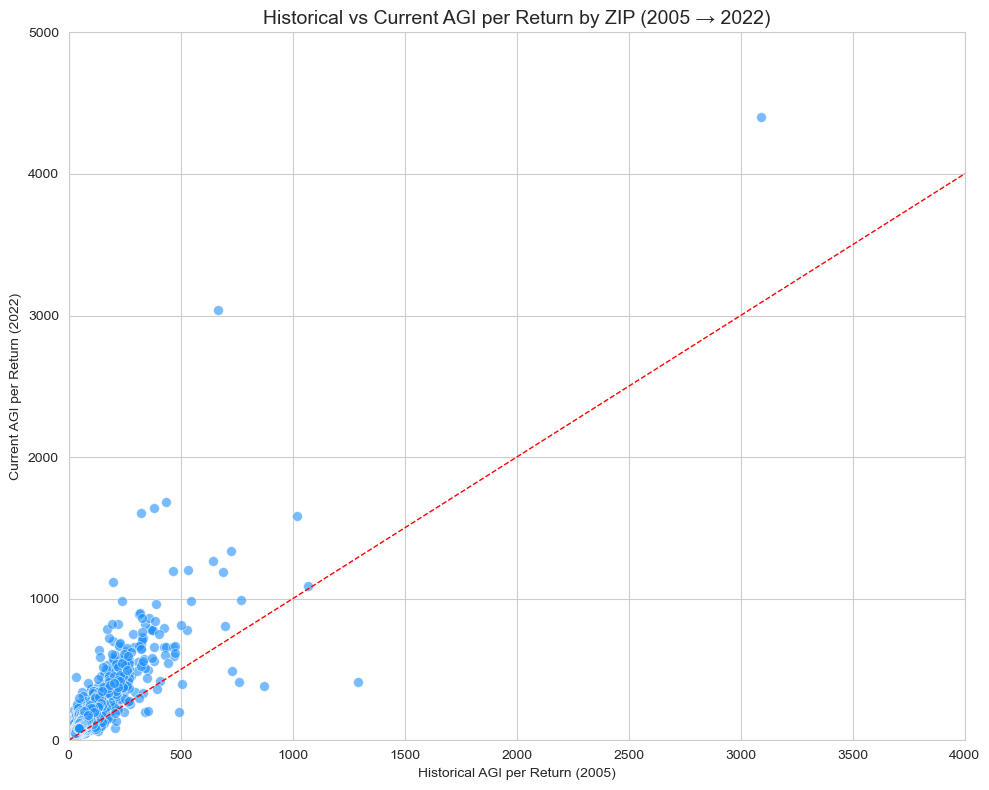

In [17]:
# Compute AGI per return
pivot_df["avg_agi_2005"] = pivot_df["A00100_2005"] / pivot_df["N1_2005"]
pivot_df["avg_agi_2022"] = pivot_df["A00100_2022"] / pivot_df["N1_2022"]

# Plot Scatter
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Scatter points
sns.scatterplot(
    data=pivot_df,
    x="avg_agi_2005",
    y="avg_agi_2022",
    alpha=0.6,
    s=50,
    color="dodgerblue"
)

# Diagonal line y = x
max_val = max(pivot_df["avg_agi_2005"].max(), pivot_df["avg_agi_2022"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1)

plt.xlim(0, 4000) 
plt.ylim(0, 5000) 

plt.title("Historical vs Current AGI per Return by ZIP (2005 → 2022)", fontsize=14)
plt.xlabel("Historical AGI per Return (2005)")
plt.ylabel("Current AGI per Return (2022)")

plt.tight_layout()
plt.show()

### Average AGI per return & Percent change per ZIP & Histogram + KDE

Shows the overall pattern across all ZIP codes, not just extremes.  
Captures the proportion of ZIPs experiencing growth vs decline, and the magnitude of changes.  

Focuses on income per filer  
Shows relative growth or decline for each ZIP.  
X-axis = % change in avg AGI per return  
Y-axis = number of ZIP codes  
KDE line shows a smooth estimate of the distribution.  

Chart Captures -  
Overall trends in household income across ZIP codes  
Proportion of ZIPs growing vs shrinking  
Magnitude of change  
Income polarization or stability

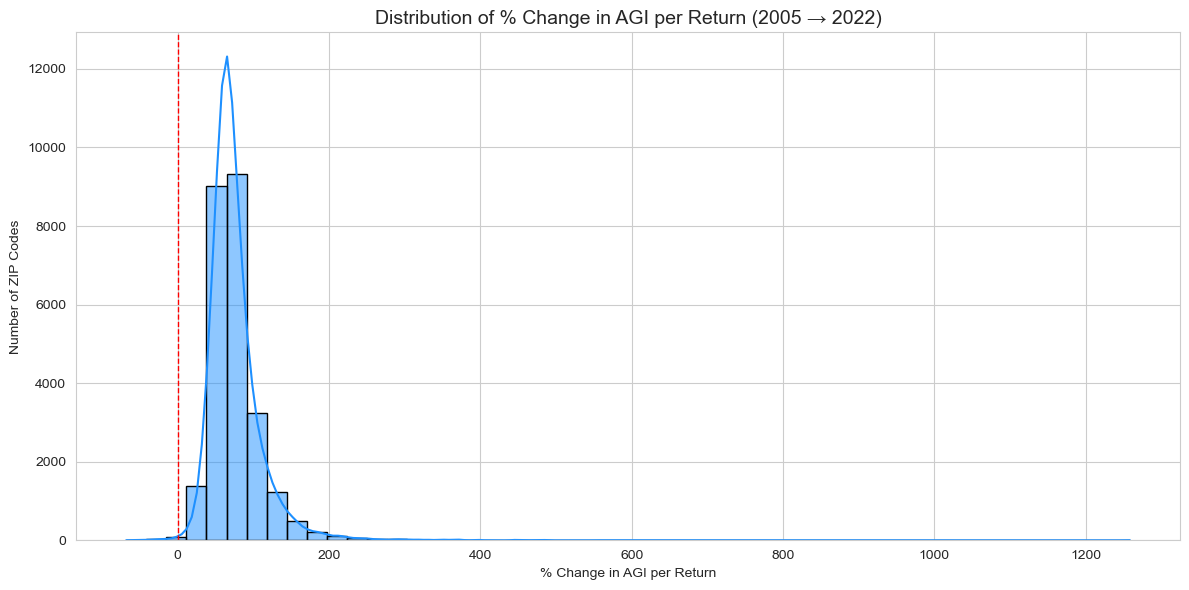

In [18]:
# Compute AGI per return & % change
pivot_df["avg_agi_2005"] = pivot_df["A00100_2005"] / pivot_df["N1_2005"]
pivot_df["avg_agi_2022"] = pivot_df["A00100_2022"] / pivot_df["N1_2022"]

pivot_df["avg_agi_pct_change"] = ((pivot_df["avg_agi_2022"] - pivot_df["avg_agi_2005"]) / pivot_df["avg_agi_2005"]) * 100

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.histplot(
    pivot_df["avg_agi_pct_change"],
    bins=50,
    kde=True,
    color="dodgerblue",
    edgecolor="black"
)

plt.axvline(0, color="red", linestyle="--", linewidth=1)  # zero-change line

plt.title("Distribution of % Change in AGI per Return (2005 → 2022)", fontsize=14)
plt.xlabel("% Change in AGI per Return")
plt.ylabel("Number of ZIP Codes")

plt.tight_layout()
plt.show()

### Line Chart
Rising line: Increasing household income → lower lending risk  
Falling line: Shrinking household income → higher lending risk  
Line that peaks then drops: Emerging risk zone — previously strong, now deteriorating  

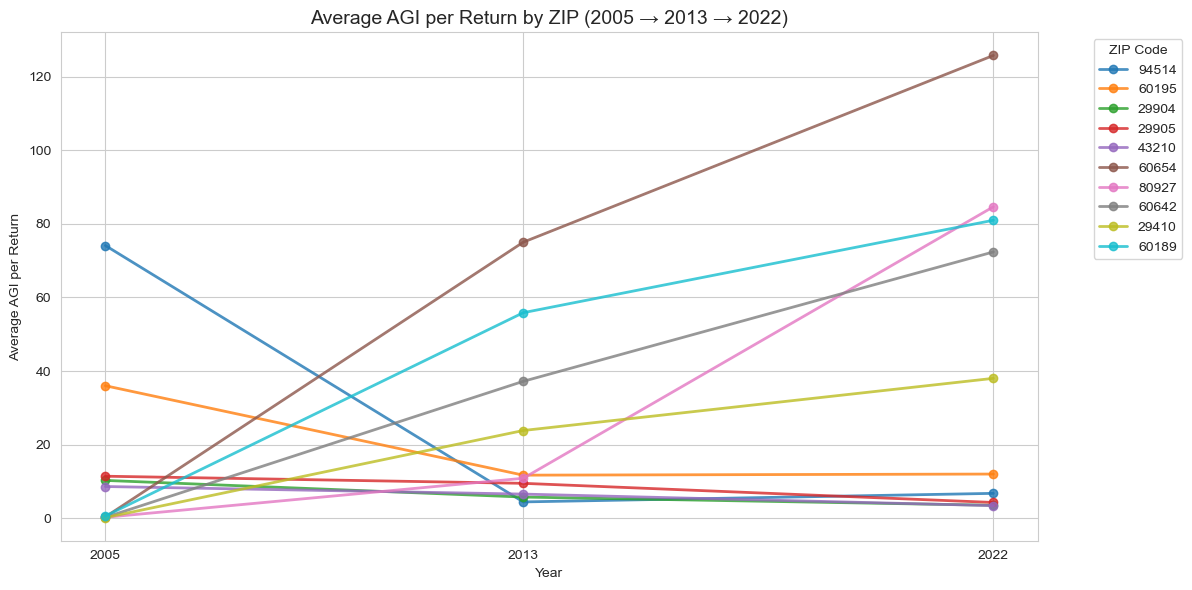

In [19]:
# Compute avg AGI per filer
avg_n_returns = master_df.groupby('zipcode')['N1'].sum()
zip_pivot['avg_agi_2005'] = zip_pivot[2005] / avg_n_returns
zip_pivot['avg_agi_2013'] = zip_pivot[2013] / avg_n_returns
zip_pivot['avg_agi_2022'] = zip_pivot[2022] / avg_n_returns

# Select top shrinking / growing ZIPs
zip_pivot['pct_change'] = ((zip_pivot['avg_agi_2022'] - zip_pivot['avg_agi_2005']) / zip_pivot['avg_agi_2005']) * 100

top_growth = zip_pivot.nlargest(5, 'pct_change')
top_decline = zip_pivot.nsmallest(5, 'pct_change')

# Combine for plotting
plot_df = pd.concat([top_decline, top_growth])

# Prepare data for line plotting (rows = years, columns = ZIPs)
plot_df = plot_df[['avg_agi_2005','avg_agi_2013','avg_agi_2022']].transpose()
plot_df.index = [2005, 2013, 2022]

# Assign unique colors to each ZIP
zips = plot_df.columns
n_zips = len(zips)
palette = sns.color_palette("tab10", n_colors=n_zips)  # one color per ZIP

# Plot line chart
plt.figure(figsize=(12, 6))

for i, zip_code in enumerate(zips):
    plt.plot(
        plot_df.index,
        plot_df[zip_code],
        marker='o',
        color=palette[i],      # unique color per ZIP
        label=zip_code,
        linewidth=2,
        alpha=0.8
    )

plt.title("Average AGI per Return by ZIP (2005 → 2013 → 2022)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average AGI per Return")
plt.xticks([2005, 2013, 2022])
plt.grid(True)
plt.legend(title="ZIP Code", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()